### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from utils import * 
from FAPT import * 
from pulse_optimization import *
import sympy as sp

# Optimization use

In [ ]:
def fitted_pulse(coeffs,cos_wd, cos_amp) -> tuple[sp.Expr, sp.Expr]:
  """Erstellt A_expr (c_amp skaliert nur A_r) und wd_expr (c_dwd_offset als Frequenz-Shift)."""
  wd = coeffs[0]+ cos_wd
  A_r = coeffs[1]+ cos_amp
  return A_r, wd 

s = Simulation()
rH = 2
rW = 1
tg, sigma_ratio = 250.0, 0.3
cos_amp, cos_wd = compute_cos_params(s, tg)

# Parametergrenzen für c_amp und c_dwd_offset holen
param_ranges = {
    "wd_offset": (-0.001,0.001),
    "amp_offset": (-0.05, 0.05),
}

# 1. Einmalige symbolische Vorberechnung von H_func und M_func
H_func, M_func = prepare_floquet_functions(
    pulse_shape_builder=lambda t, p: fitted_pulse(p, cos_wd, cos_amp),
    p_names=list(param_ranges.keys()),
    s=s,
    rH=rH,
    rW=rW,
    include_geometric=False,
    include_micromotion=False,
    include_g_correction=False,
    verbose=False,
)

In [4]:
# --- Setup für extrem schnelle Konvergenz (2 Parameter) ---
best_p, best_infid, best_psi_t, tlist = optimize_pulse_parameters(
    H_func=H_func,
    M_func=M_func,
    param_ranges=param_ranges,
    s=s,
    tg=tg,
    N_t=100,
    target_metric="process",
    verbose=True,
    # Tuning für 2D-Parameterraum:
    popsize=4,  # Bei 2 Parametern reichen 4-6 Individuen pro Generation
    maxiter=15,  # Konvergiert in 2D extrem schnell
    tol=1e-8,
    mutation=(0.2, 0.6),
    recombination=0.9,
    polish=True,  # L-BFGS-B findet das exakte Minimum am Ende im 2D-Raum in Millisekunden
    workers=1,
)

[DEBUG] Starte Puls-Optimierung
[DEBUG] Parameter (2): ['wd_offset', 'amp_offset']
[DEBUG] Hilbertraum D=27, Reduzierter Raum d_res=3, N_t=100
[DEBUG] Popsize=4 -> 8 Evall. pro Generation | Maxiter=15 | Workers=1
[DEBUG] Starte differential_evolution...
differential_evolution step 1: f(x)= 0.761466501847308
[DEBUG Gen Callback] Aufrufe:     16 | Bisher beste Infidelity: 7.614665e-01 | Conv: 3.1599e-07 | Zeit: 0.06s
differential_evolution step 2: f(x)= 0.761466501847308
[DEBUG Gen Callback] Aufrufe:     24 | Bisher beste Infidelity: 7.614665e-01 | Conv: 4.1987e-07 | Zeit: 0.09s
differential_evolution step 3: f(x)= 0.749747292452866
[DEBUG Gen Callback] Aufrufe:     32 | Bisher beste Infidelity: 7.497473e-01 | Conv: 1.2143e-06 | Zeit: 0.13s
differential_evolution step 4: f(x)= 0.7439693028816459
[DEBUG Gen Callback] Aufrufe:     40 | Bisher beste Infidelity: 7.439693e-01 | Conv: 8.3034e-07 | Zeit: 0.16s
differential_evolution step 5: f(x)= 0.742529906851735
[DEBUG Gen Callback] Aufrufe: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pulse_optimization import (
    compute_pulse_infidelity,
    optimize_pulse_parameters,
    prepare_floquet_functions,
    refine_gate_time,
)
from tqdm import tqdm


# ==============================================================================
# 1. Sequential-Optimierungs- & Simulations-Logik
# ==============================================================================
def run_single_tg_sequential_optimization(
    tg_target,
    s,
    rH,
    rW,
    param_ranges,
    res_keys,
    ia,
    ib,
    pts_per_ns=10.0,
    steps_per_ns=2.0,
):
  cos_amp, cos_wd = compute_cos_params(s, tg_target)

  # --- SCHRITT 1: Population Fidelity Optimierung ---
  H_func, M_func = prepare_floquet_functions(
      pulse_shape_builder=lambda t, p: fitted_pulse(p, cos_wd, cos_amp),
      p_names=list(param_ranges.keys()),
      s=s,
      rH=rH,
      rW=rW,
      include_geometric=False,
      include_micromotion=False,
      include_g_correction=False,
      verbose=False,
  )

  best_p_pop, best_infid_pop, _, _ = optimize_pulse_parameters(
      H_func=H_func,
      M_func=M_func,
      param_ranges=param_ranges,
      s=s,
      tg=tg_target,
      N_t=100,
      target_metric="population",
      verbose=False,
      popsize=4,
      maxiter=15,
      tol=1e-8,
      polish=True,
  )

  wd_offset_opt = best_p_pop.get("wd_offset", 0.0)
  amp_offset_opt = best_p_pop.get("amp_offset", 0.0)

  wd_val_pop = wd_offset_opt + cos_wd
  Ar_val_pop = amp_offset_opt + cos_amp
  q_sig_pop = lambda t, args=None: Ar_val_pop * np.cos(wd_val_pop * t)

  # mesolve Simulation für Population Metric
  n_pts_pop = max(101, int(np.ceil(tg_target * pts_per_ns)))
  t_mes_pop = np.linspace(0, tg_target, n_pts_pop)

  amp_a_pop = resonant_subspace_column_evolution(
      [s.H0, [s.V1, q_sig_pop]], t_mes_pop, ia, debug=False, s=s
  )
  amp_b_pop = resonant_subspace_column_evolution(
      [s.H0, [s.V1, q_sig_pop]], t_mes_pop, ib, debug=False, s=s
  )
  mes_infid_pop = 1.0 - 0.5 * (
      np.abs(amp_a_pop[ib, -1]) ** 2 + np.abs(amp_b_pop[ia, -1]) ** 2
  )

  # --- SCHRITT 2: Process Fidelity Optimierung (Gate Time Refinement auf Periode T = 2pi / wd) ---
  best_tg_proc, best_infid_proc = refine_gate_time(
      best_p_pop=best_p_pop,
      tg_target=tg_target,
      wd_val=wd_val_pop,
      H_func=H_func,
      M_func=M_func,
      s=s,
      res_keys=res_keys,
      steps_per_ns=steps_per_ns,
  )

  # mesolve Simulation für best_tg_proc
  n_pts_proc = max(101, int(np.ceil(best_tg_proc * pts_per_ns)))
  t_mes_proc = np.linspace(0, best_tg_proc, n_pts_proc)

  amp_a_proc = resonant_subspace_column_evolution(
      [s.H0, [s.V1, q_sig_pop]], t_mes_proc, ia, debug=False, s=s
  )
  amp_b_proc = resonant_subspace_column_evolution(
      [s.H0, [s.V1, q_sig_pop]], t_mes_proc, ib, debug=False, s=s
  )
  mes_infid_proc = 1.0 - 0.5 * (
      np.abs(amp_a_proc[ib, -1]) ** 2 + np.abs(amp_b_proc[ia, -1]) ** 2
  )

  return (
      best_infid_pop,
      mes_infid_pop,
      best_infid_proc,
      mes_infid_proc,
      best_tg_proc,
      wd_offset_opt,
      amp_offset_opt,
  )


def run_gate_time_sweep(tg_list, s, rH=2, rW=1, pts_per_ns=10.0, steps_per_ns=2.0):
  param_ranges = {"wd_offset": (-0.001, 0.001), "amp_offset": (-0.05, 0.05)}
  res_keys = list(
      s.resonances.keys()
      if isinstance(s.resonances, dict)
      else dict(s.resonances).keys()
  )
  ia, ib = res_keys.index(s.state_a), res_keys.index(s.state_b)

  results = {
      "floq_pop": [],
      "mes_pop": [],
      "floq_proc": [],
      "mes_proc": [],
      "tg_opt": [],
      "wd_offset": [],
      "amp_offset": [],
  }

  for tg in tqdm(tg_list, desc="Sequential Gate-Time Sweep", unit="tg"):
    f_pop, m_pop, f_proc, m_proc, tg_opt, wd_opt, amp_opt = (
        run_single_tg_sequential_optimization(
            tg,
            s,
            rH,
            rW,
            param_ranges,
            res_keys,
            ia,
            ib,
            pts_per_ns=pts_per_ns,
            steps_per_ns=steps_per_ns,
        )
    )
    results["floq_pop"].append(f_pop)
    results["mes_pop"].append(m_pop)
    results["floq_proc"].append(f_proc)
    results["mes_proc"].append(m_proc)
    results["tg_opt"].append(tg_opt)
    results["wd_offset"].append(wd_opt)
    results["amp_offset"].append(amp_opt)

  return results


# --- Ausführung der Berechnung ---
s = Simulation()
tg_list = np.linspace(50.0, 1000.0, 10)

sweep_data = run_gate_time_sweep(tg_list, s, pts_per_ns=10.0, steps_per_ns=2.0)

Sequential Gate-Time Sweep: 100%|██████████| 10/10 [00:54<00:00,  5.49s/tg]


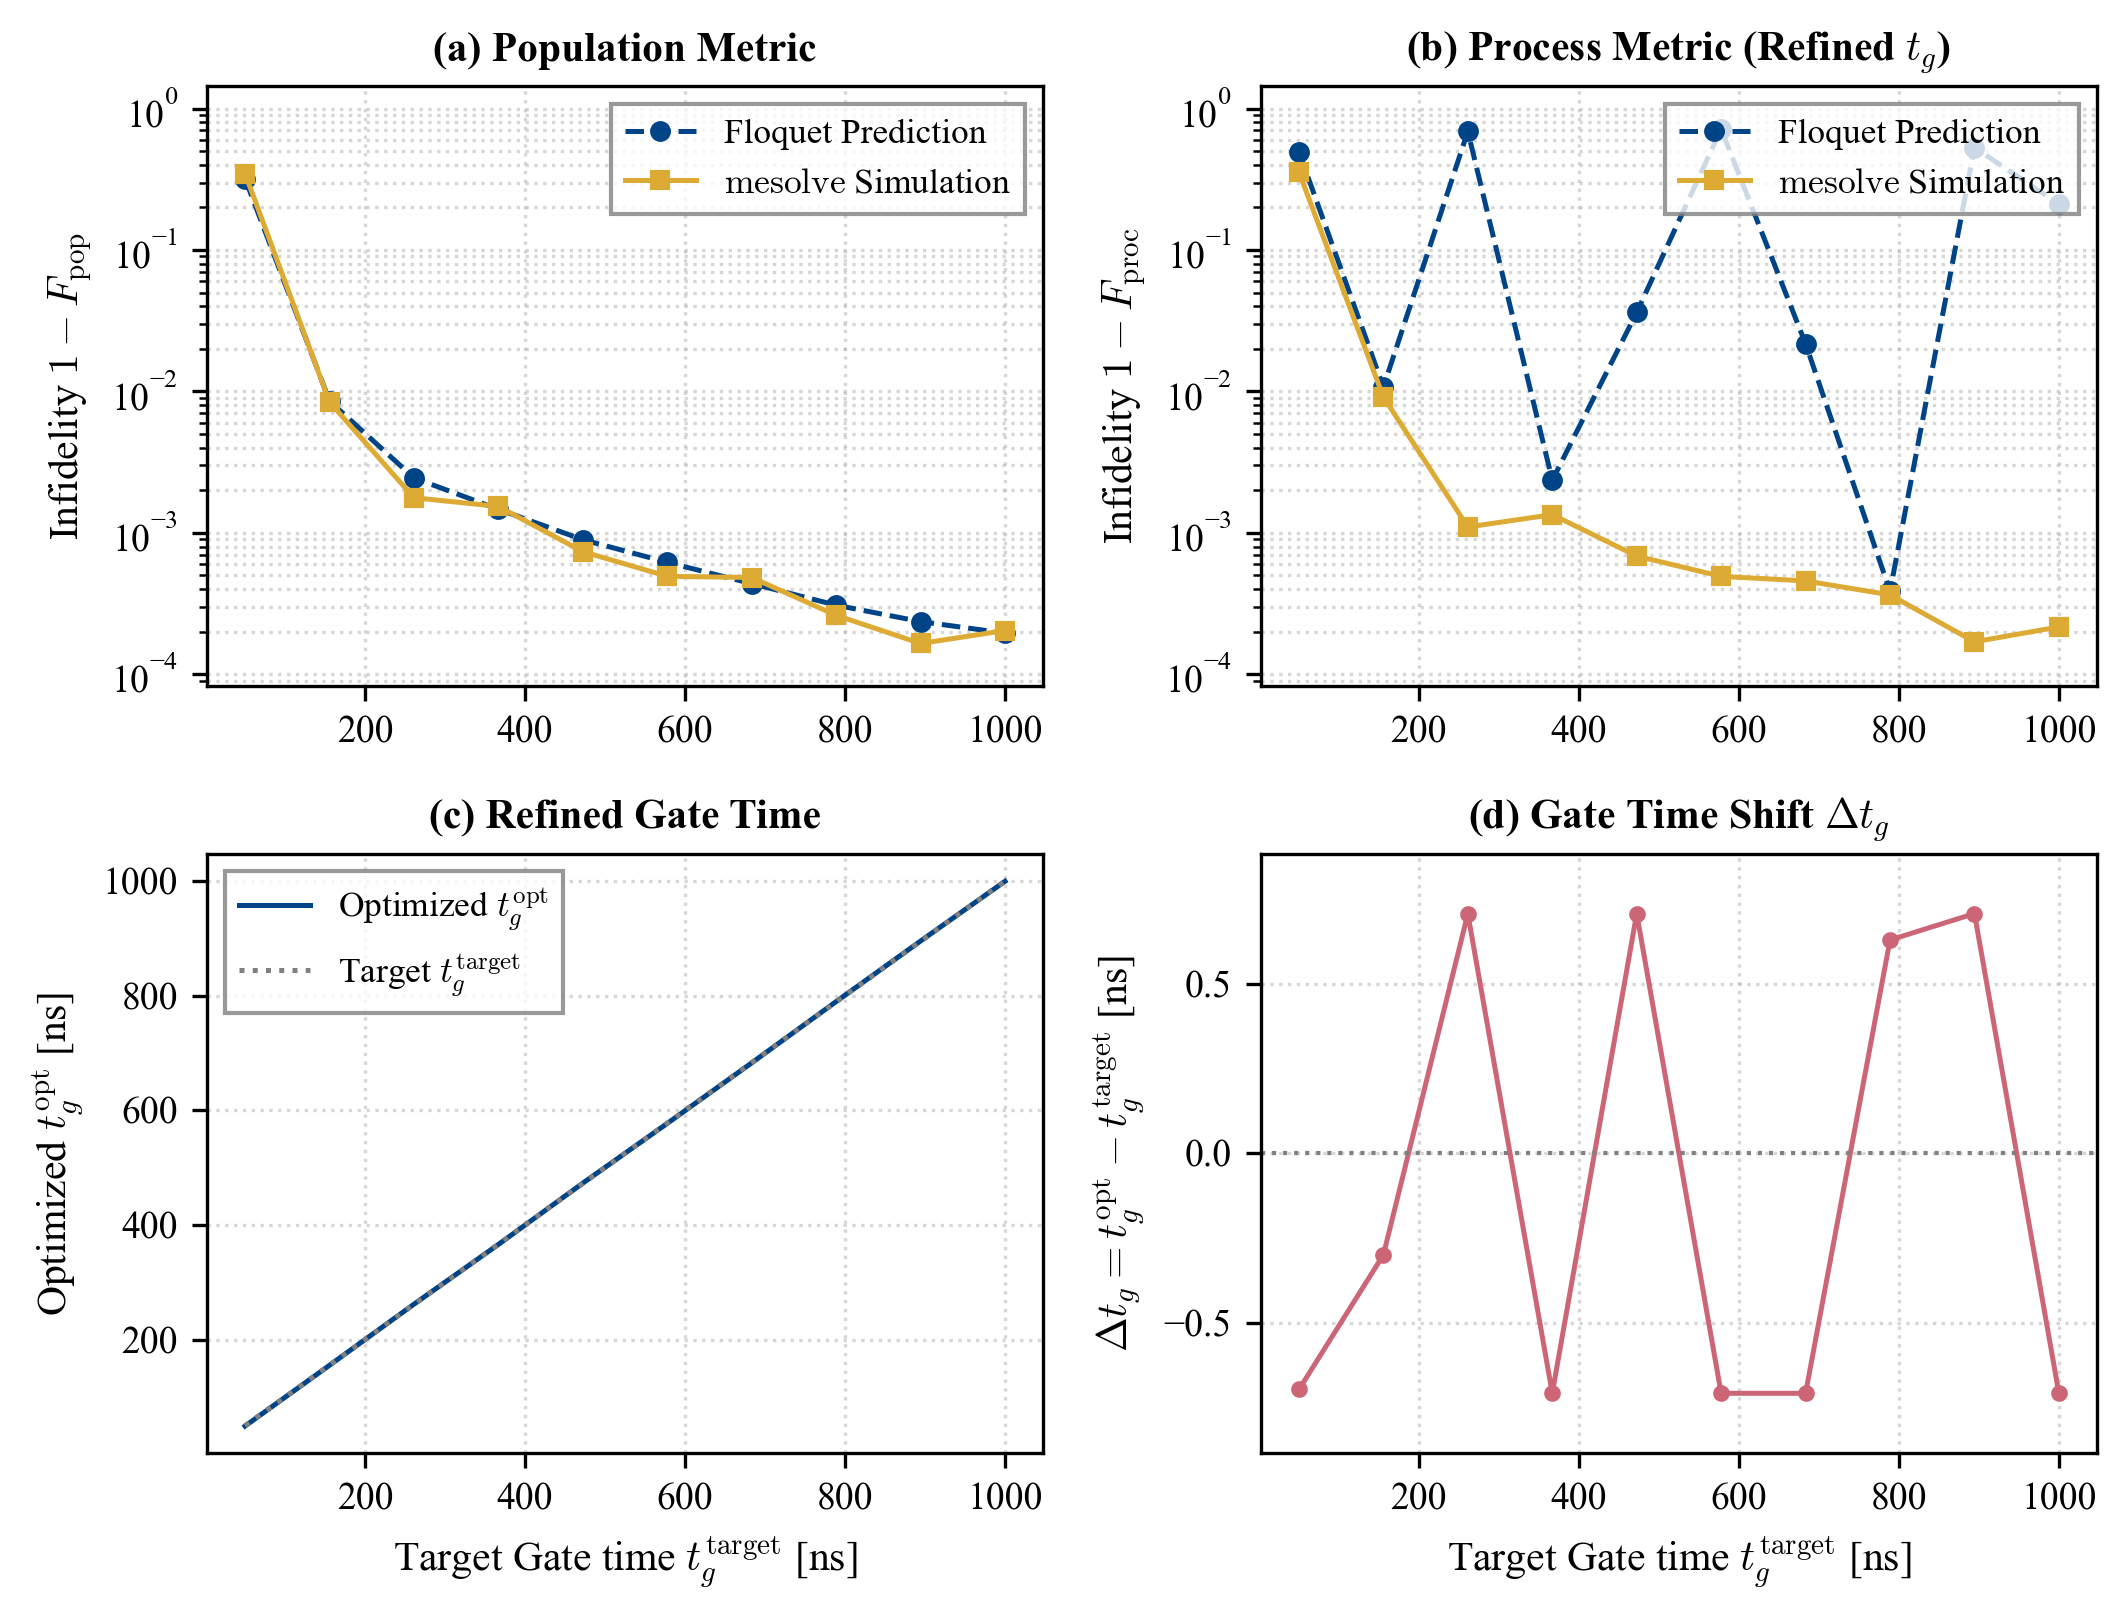

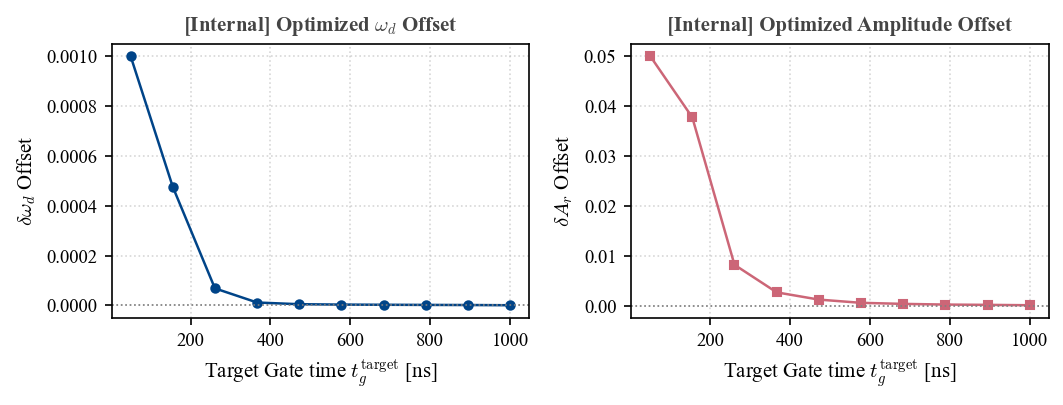

In [7]:
# ==============================================================================
# 2. Paper-Style Plotting
# ==============================================================================
def setup_paper_style():
  """Richtet Matplotlib-Standards für wissenschaftliche Publikationen ein."""
  plt.rcParams.update({
      "font.family": "serif",
      "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
      "mathtext.fontset": "cm",
      "text.usetex": False,
      "axes.labelsize": 10,
      "font.size": 10,
      "legend.fontsize": 8.5,
      "xtick.labelsize": 9,
      "ytick.labelsize": 9,
      "figure.titlesize": 11,
      "axes.titlesize": 10,
      "lines.linewidth": 1.2,
      "lines.markersize": 4,
  })


def plot_infidelity_sweep(tg_list, results):
  """Erstellt das 2x2 Publication Layout mit Infidelity Plots und tg-Anpassung.

  Wird als PDF für das Paper gespeichert.
  """
  setup_paper_style()

  # sharey="row" deaktiviert, um eine eigenständige, engere Skalierung für Panel (d) zu erlauben
  fig, axs = plt.subplots(2, 2, figsize=(7.2, 5.5), dpi=300)
  (ax1, ax2), (ax3, ax4) = axs

  c_floq, c_mes, c_diff = "#004488", "#DDAA33", "#CC6677"
  m_floq, m_mes = "o", "s"

  # --- Panel A: Population Infidelity ---
  ax1.semilogy(
      tg_list,
      results["floq_pop"],
      f"{m_floq}--",
      color=c_floq,
      label=r"Floquet Prediction",
  )
  ax1.semilogy(
      tg_list,
      results["mes_pop"],
      f"{m_mes}-",
      color=c_mes,
      label=r"$\mathrm{mesolve}$ Simulation",
  )
  ax1.set_ylabel(r"Infidelity $1 - F_{\mathrm{pop}}$")
  ax1.set_title(r"(a) Population Metric", fontweight="bold")
  ax1.grid(True, which="both", linestyle=":", alpha=0.5)
  ax1.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

  # --- Panel B: Process Infidelity ---
  ax2.semilogy(
      tg_list,
      results["floq_proc"],
      f"{m_floq}--",
      color=c_floq,
      label=r"Floquet Prediction",
  )
  ax2.semilogy(
      tg_list,
      results["mes_proc"],
      f"{m_mes}-",
      color=c_mes,
      label=r"$\mathrm{mesolve}$ Simulation",
  )
  ax2.set_ylabel(r"Infidelity $1 - F_{\mathrm{proc}}$")
  ax2.tick_params(labelleft=True)
  ax2.set_title(r"(b) Process Metric (Refined $t_g$)", fontweight="bold")
  ax2.grid(True, which="both", linestyle=":", alpha=0.5)
  ax2.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

  # Y-Achsen von Panel (a) und (b) angleichen für Konsistenz
  y_min = min(
      min(results["floq_pop"]),
      min(results["mes_pop"]),
      min(results["floq_proc"]),
      min(results["mes_proc"]),
  )
  y_max = max(
      max(results["floq_pop"]),
      max(results["mes_pop"]),
      max(results["floq_proc"]),
      max(results["mes_proc"]),
  )
  ax1.set_ylim(y_min * 0.5, y_max * 2.0)
  ax2.set_ylim(y_min * 0.5, y_max * 2.0)

  # --- Panel C: Absolute optimierte Gate-Zeit ---
  tg_opt = np.array(results["tg_opt"])
  delta_tg = tg_opt - np.array(tg_list)

  ax3.plot(
      tg_list,
      tg_opt,
      "-",
      color=c_floq,
      label=r"Optimized $t_g^{\mathrm{opt}}$",
  )
  ax3.plot(
      tg_list,
      tg_list,
      ":",
      color="gray",
      label=r"Target $t_g^{\mathrm{target}}$",
  )
  ax3.set_xlabel(r"Target Gate time $t_g^{\mathrm{target}}$ [ns]")
  ax3.set_ylabel(r"Optimized $t_g^{\mathrm{opt}}$ [ns]")
  ax3.set_title(r"(c) Refined Gate Time", fontweight="bold")
  ax3.grid(True, linestyle=":", alpha=0.5)
  ax3.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper left")

  # --- Panel D: Abweichung Δtg (Automatisch skaliert) ---
  ax4.plot(tg_list, delta_tg, "o-", color=c_diff, markersize=3)
  ax4.axhline(0, color="gray", linestyle=":", linewidth=1)
  ax4.set_xlabel(r"Target Gate time $t_g^{\mathrm{target}}$ [ns]")
  ax4.set_ylabel(
      r"$\Delta t_g = t_g^{\mathrm{opt}} - t_g^{\mathrm{target}}$ [ns]"
  )
  ax4.tick_params(labelleft=True)
  ax4.set_title(r"(d) Gate Time Shift $\Delta t_g$", fontweight="bold")
  ax4.grid(True, linestyle=":", alpha=0.5)

  # Dynamic Limits mit min 10% Padding, damit der Plot nicht am Rand klebt
  max_dev = max(abs(np.min(delta_tg)), abs(np.max(delta_tg)))
  if max_dev > 0:
    ax4.set_ylim(-max_dev * 1.25, max_dev * 1.25)

  plt.tight_layout()
  plt.savefig("Figure/infidelity_vs_gate_time_cosdrive.pdf", bbox_inches="tight")
  plt.show()


def plot_internal_parameter_offsets(tg_list, results):
  """Erstellt eine separate Abbildung für die internen Parameter-Offsets.

  Wird NICHT als PDF gespeichert.
  """
  setup_paper_style()

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 2.8), dpi=150)

  c_wd, c_amp = "#004488", "#CC6677"

  # Links: Frequency Offset wd
  ax1.plot(tg_list, results["wd_offset"], "o-", color=c_wd)
  ax1.axhline(0, color="gray", linestyle=":", linewidth=0.8)
  ax1.set_xlabel(r"Target Gate time $t_g^{\mathrm{target}}$ [ns]")
  ax1.set_ylabel(r"$\delta\omega_d$ Offset")
  ax1.set_title(
      r"[Internal] Optimized $\omega_d$ Offset",
      fontweight="bold",
      color="#444444",
  )
  ax1.grid(True, linestyle=":", alpha=0.5)

  # Rechts: Amplitude Offset amp
  ax2.plot(tg_list, results["amp_offset"], "s-", color=c_amp)
  ax2.axhline(0, color="gray", linestyle=":", linewidth=0.8)
  ax2.set_xlabel(r"Target Gate time $t_g^{\mathrm{target}}$ [ns]")
  ax2.set_ylabel(r"$\delta A_r$ Offset")
  ax2.set_title(
      r"[Internal] Optimized Amplitude Offset",
      fontweight="bold",
      color="#444444",
  )
  ax2.grid(True, linestyle=":", alpha=0.5)

  plt.tight_layout()
  plt.show()


# --- Plots erzeugen ---
# 1. Haupt-Publication Plot (wird in 'infidelity_vs_gate_time.pdf' gespeichert)
plot_infidelity_sweep(tg_list, sweep_data)

# 2. Interner Kontroll-Plot (wird nicht gespeichert)
plot_internal_parameter_offsets(tg_list, sweep_data)